In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

I0000 00:00:1786954671.824572    8261 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786954671.852981    8261 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786954671.890333    8261 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786954677.637842    8261 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images :", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images : (10000, 28, 28)


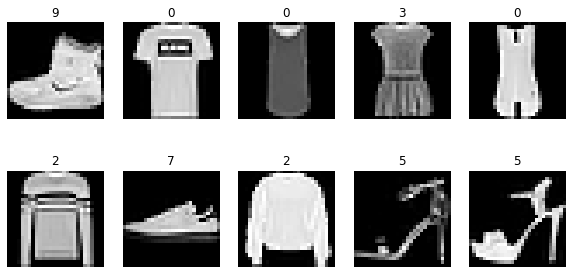

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [4]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
k_values = [1, 3, 5, 7, 9]

accuracy = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    predictions = knn.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    accuracy.append(acc)

    print(f"K = {k}  Accuracy = {acc:.4f}")

K = 1  Accuracy = 0.8413
K = 3  Accuracy = 0.8496
K = 5  Accuracy = 0.8533
K = 7  Accuracy = 0.8524
K = 9  Accuracy = 0.8494


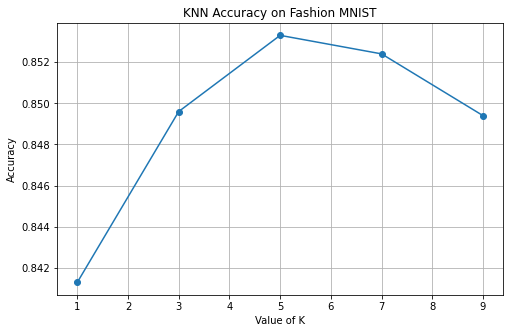

In [7]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy, marker='o')

plt.xlabel("Value of K")

plt.ylabel("Accuracy")

plt.title("KNN Accuracy on Fashion MNIST")

plt.grid(True)

plt.show()

In [15]:
best_k = k_values[np.argmax(accuracy)]

print("Best K:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

prediction = knn.predict(X_test)

print(classification_report(y_test, prediction))

Best K: 5
              precision    recall  f1-score   support

           0       0.77      0.86      0.81      1000
           1       0.99      0.96      0.98      1000
           2       0.74      0.80      0.77      1000
           3       0.90      0.86      0.88      1000
           4       0.77      0.77      0.77      1000
           5       0.99      0.84      0.91      1000
           6       0.64      0.59      0.61      1000
           7       0.88      0.96      0.92      1000
           8       0.98      0.93      0.95      1000
           9       0.90      0.96      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Lists to store results
accuracy_results = []
precision_results = []
recall_results = []
f1_results = []

In [17]:
# Run KNN again for each K and calculate all metrics
for k in k_values:

    knn_temp = KNeighborsClassifier(n_neighbors=k)

    knn_temp.fit(X_train, y_train)

    predictions_temp = knn_temp.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, predictions_temp)

    # Precision
    precision = precision_score(
        y_test,
        predictions_temp,
        average='weighted',
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_test,
        predictions_temp,
        average='weighted',
        zero_division=0
    )

    # F1-score
    f1 = f1_score(
        y_test,
        predictions_temp,
        average='weighted',
        zero_division=0
    )

    accuracy_results.append(acc)
    precision_results.append(precision)
    recall_results.append(recall)
    f1_results.append(f1)

    print(
        f"K={k} | "
        f"Accuracy={acc:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )


K=1 | Accuracy=0.8413 | Precision=0.8459 | Recall=0.8413 | F1=0.8427
K=3 | Accuracy=0.8496 | Precision=0.8528 | Recall=0.8496 | F1=0.8497
K=5 | Accuracy=0.8533 | Precision=0.8565 | Recall=0.8533 | F1=0.8534
K=7 | Accuracy=0.8524 | Precision=0.8557 | Recall=0.8524 | F1=0.8524
K=9 | Accuracy=0.8494 | Precision=0.8531 | Recall=0.8494 | F1=0.8496


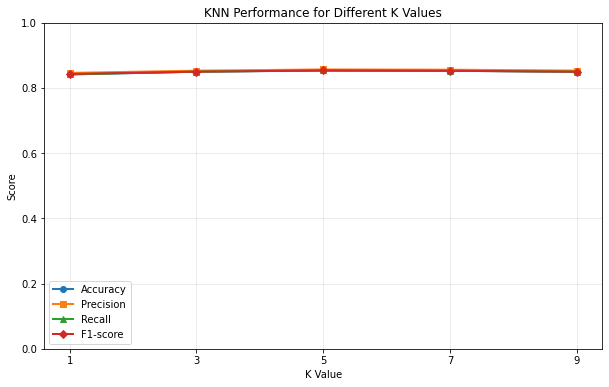

In [14]:

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracy_results,
    marker='o',
    linewidth=2,
    label='Accuracy'
)

plt.plot(
    k_values,
    precision_results,
    marker='s',
    linewidth=2,
    label='Precision'
)

plt.plot(
    k_values,
    recall_results,
    marker='^',
    linewidth=2,
    label='Recall'
)

plt.plot(
    k_values,
    f1_results,
    marker='D',
    linewidth=2,
    label='F1-score'
)

plt.xlabel("K Value")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")

plt.xticks(k_values)
plt.ylim(0, 1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


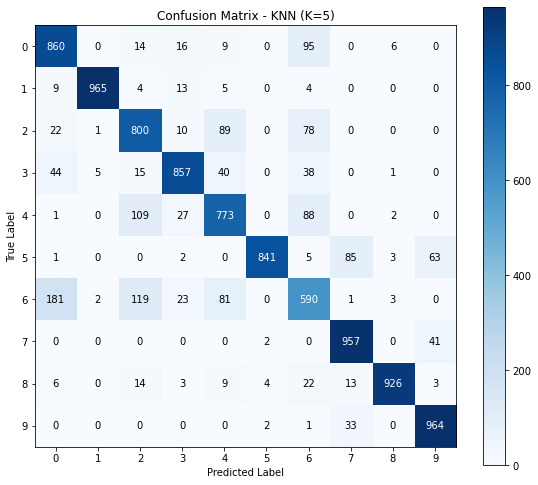

In [18]:

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(8, 7))

plt.imshow(cm, cmap='Blues')

plt.title(f"Confusion Matrix - KNN (K={best_k})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

# Add numbers inside confusion matrix
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black'
        )

plt.tight_layout()
plt.show()